# Chapitre 7 — EDA analytique

**Durée estimée : 10-12 heures**

---

## Objectifs d'apprentissage

À la fin de ce chapitre, vous serez capable de :

1. **Analyser** la distribution d'une variable et interpréter ses caractéristiques statistiques
2. **Identifier** les relations entre variables (corrélation, associations)
3. **Comparer** des sous-populations et détecter des patterns significatifs
4. **Formuler** des hypothèses à partir des observations et éviter les pièges d'interprétation

---

## 7.4 Segmentation et analyse par groupes

### Identifier des sous-populations

Le point de départ : "Imaginez que vous avez 1 000 clients. Leurs dépenses vont de 5 € à 1 000 €. Si vous voulez faire une campagne marketing, vous n'allez pas faire une offre différente pour chaque centime. Vous voulez faire 4 groupes de taille égale (250 personnes chacun)."

Scénario : Vous analysez le montant total des achats des clients d'un site e-commerce.

Questions :

1. L'équilibre : "Si je coupe tous les 200 € (0-200, 200-400...), et que 90% des clients dépensent moins de 50 €, que va-t-il se passer pour mes groupes ?" (Réponse : Un groupe sera surchargé, les autres seront presque vides).

2. La justice statistique : "Comment s'appelle l'outil qui permet de couper les données pour qu'il y ait exactement le même nombre d'individus dans chaque tranche ?" (Réponse : Les Quantiles).

3. L'interprétation : "Une fois que j'ai mes 4 groupes (Quartiles), quel groupe m'intéresse le plus si je veux augmenter mon chiffre d'affaires ?"

L'objectif : Comprendre que pd.qcut (Quantile-based cut) crée des segments de population équilibrés, contrairement à pd.cut qui crée des segments de largeur égale.

Nombre de clients par segment :
Segment
Bronze     250
Argent     250
Or         250
Platine    250
Name: count, dtype: int64


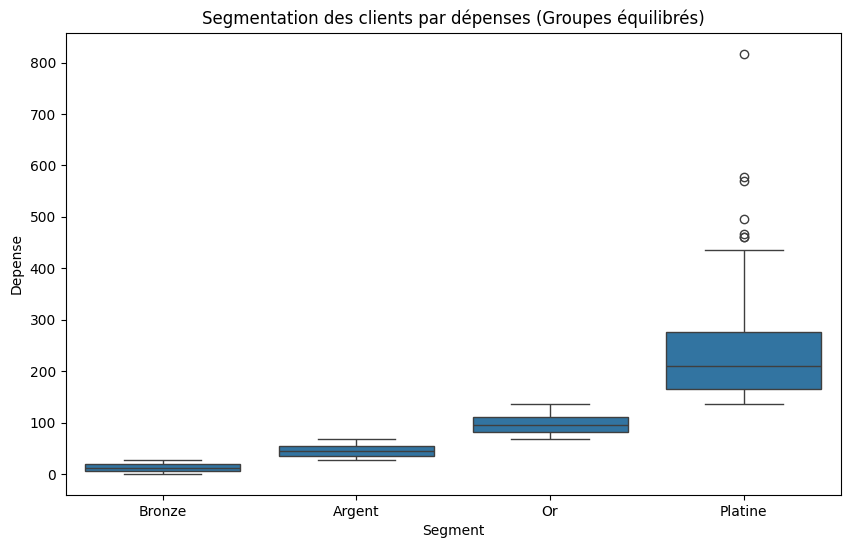

In [ ]:
# 🛠️ Visualisation Python : Segmenter avec pd.qcut
# Voici comment transformer une dépense en "Catégorie de client" et vérifier que nos groupes sont bien équilibrés.

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# 1. Création de données (Dépenses clients souvent très asymétriques)
np.random.seed(42)
depenses = np.random.exponential(100, 1000) # Beaucoup de petits, peu de gros
df_clients = pd.DataFrame({'Depense': depenses})

# 2. Segmentation en 4 groupes égaux (Quartiles)
df_clients['Segment'] = pd.qcut(df_clients['Depense'], q=4, labels=['Bronze', 'Argent', 'Or', 'Platine'])

# 3. Vérification des effectifs
print("Nombre de clients par segment :")
print(df_clients['Segment'].value_counts())

# 4. Visualisation de l'analyse par groupe
plt.figure(figsize=(10, 6))
sns.boxplot(x='Segment', y='Depense', data=df_clients)
plt.title("Segmentation des clients par dépenses (Groupes équilibrés)")
plt.show()

Maintenant que nous avons nos étiquettes 'Bronze', 'Argent', 'Or', 'Platine', à quoi cela nous sert-il ?"

Question : "Si j'ajoute une colonne 'Nombre de visites', comment savoir si les clients 'Platine' (ceux qui dépensent le plus) sont aussi ceux qui viennent le plus souvent ?"

L'outil : On utilise le groupby sur nos nouveaux segments.

In [8]:
# Imaginons une colonne 'Visites'
df_clients['Visites'] = np.random.poisson(5, 1000) + (df_clients['Depense'] / 20)

# Analyse : Moyenne des visites par segment
analyse = df_clients.groupby('Segment')['Visites'].mean()
print("\nNombre moyen de visites par segment :")
print(analyse)


Nombre moyen de visites par segment :
Segment
Bronze      5.492598
Argent      7.118617
Or          9.714948
Platine    16.519957
Name: Visites, dtype: float64


/var/folders/01/2dhhcg55665c5vbwq1ll5qlh0000gn/T/ipykernel_57714/3578772921.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  analyse = df_clients.groupby('Segment')['Visites'].mean()


| Fonction   | Comment elle coupe ?                            | Résultat                                    | Idéal pour...                                  |
|------------|-------------------------------------------------|---------------------------------------------|-----------------------------------------------|
| pd.cut     | Par intervalles fixes (ex: tous les 10 m).      | Groupes avec des nombres d'individus différents. | Créer des tranches d'âge (0-18, 18-25...).   |
| pd.qcut    | Par quantiles (ex: 25% des gens).               | Groupes avec le même nombre d'individus.        | Créer des segments clients (Top 10%, etc.). |

---

### ✍️ Exercice 7.4 : Segmentation clients (20 min)

In [9]:
import pandas as pd
import numpy as np

# Données e-commerce
np.random.seed(42)
n = 2000
df = pd.DataFrame({
    'client_id': range(n),
    'date_inscription': pd.date_range('2020-01-01', periods=n, freq='12H'),
    'derniere_visite': pd.date_range('2024-06-01', periods=n, freq='6H'),
    'nb_visites': np.random.randint(1, 100, n),
    'nb_achats': np.random.randint(0, 30, n),
    'montant_total': np.random.exponential(200, n),
    'canal_acquisition': np.random.choice(['Organique', 'Payant', 'Social', 'Email'], n)
})

# 1. Créer un score de valeur client (RFM simplifié)
# R = Récence (jours depuis dernière visite)
df['recence'] = (pd.Timestamp.now() - df['derniere_visite']).dt.days

# F = Fréquence (nb_achats)
# M = Montant (montant_total)

# 2. Segmenter les clients en 4 groupes de valeur
df['segment_valeur'] = pd.qcut(df['montant_total'], q=4, labels=['Bronze', 'Silver', 'Gold', 'Platinum'])

# 3. Profil de chaque segment
profil_segments = df.groupby('segment_valeur').agg({
    'client_id': 'count',
    'recence': 'mean',
    'nb_visites': 'mean',
    'nb_achats': 'mean',
    'montant_total': ['mean', 'sum']
}).round(1)

print("Profil par segment :")
print(profil_segments)

# 4. Canal d'acquisition le plus efficace par segment
print("\nCanal dominant par segment :")
for segment in ['Bronze', 'Silver', 'Gold', 'Platinum']:
    canal = df[df['segment_valeur'] == segment]['canal_acquisition'].mode()[0]
    print(f"  {segment}: {canal}")

# 5. Insights
# a) Quel segment représente le plus de valeur totale ? _____
# b) Les clients Platinum visitent-ils plus souvent ? _____
# c) Y a-t-il un canal clairement meilleur pour les hautes valeurs ? _____

Profil par segment :
               client_id recence nb_visites nb_achats montant_total          
                   count    mean       mean      mean          mean       sum
segment_valeur                                                               
Bronze               500   345.2       48.8      14.7          26.8   13420.2
Silver               500   351.5       49.5      15.3          93.5   46757.7
Gold                 500   346.6       48.9      14.0         197.6   98814.1
Platinum             500   354.6       51.6      14.0         466.6  233317.7

Canal dominant par segment :
  Bronze: Email
  Silver: Payant
  Gold: Organique
  Platinum: Payant


/var/folders/01/2dhhcg55665c5vbwq1ll5qlh0000gn/T/ipykernel_57714/1270716246.py:9: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  'date_inscription': pd.date_range('2020-01-01', periods=n, freq='12H'),
/var/folders/01/2dhhcg55665c5vbwq1ll5qlh0000gn/T/ipykernel_57714/1270716246.py:10: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  'derniere_visite': pd.date_range('2024-06-01', periods=n, freq='6H'),
/var/folders/01/2dhhcg55665c5vbwq1ll5qlh0000gn/T/ipykernel_57714/1270716246.py:28: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  profil_segments = df.groupby('segment_valeur').agg({
